In [ ]:
pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import zipfile
import os

zip_path = "/content/yolo_pothole.zip"        # path to your zip file
extract_path = "dataset"        # folder to extract to

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction completed!")


✅ Extraction completed!


In [ ]:
from ultralytics import YOLO

model_4= YOLO("yolo26m.pt")  # change to yolov8s.pt for better accuracy

model_4.train(
    data="/content/dataset/data.yaml",
    epochs=30,


)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a7d3c663920>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model_4.save('model26m_30.pt')

In [ ]:
results = model_4(
    source="/content/dataset/test/images/p1006_jpg.rf.6d601ad3863ac7e8ca5c5c2bfbc79f34.jpg",   # 👈 path to image
    conf=0.4,
    save=True,
    show=True
)

WARNING ⚠️ Environment does not support cv2.imshow() or PIL Image.show()


image 1/1 /content/dataset/test/images/p1006_jpg.rf.6d601ad3863ac7e8ca5c5c2bfbc79f34.jpg: 640x640 1 hole, 37.5ms
Speed: 3.2ms preprocess, 37.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict



image 1/1 /content/dataset/test/images/p1058_jpg.rf.5fe6d9e4e42b108e74fbab961bb52b3b.jpg: 640x640 1 hole, 37.5ms
Speed: 3.0ms preprocess, 37.5ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

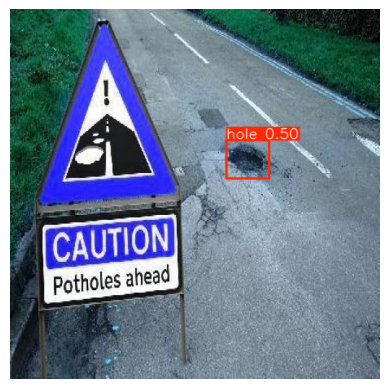

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

results = model_4("/content/dataset/test/images/p1058_jpg.rf.5fe6d9e4e42b108e74fbab961bb52b3b.jpg", conf=0.4)

annotated_img = results[0].plot()  # image with detections

plt.imshow(annotated_img)
plt.axis("off")


image 1/1 /content/dataset/test/images/p1359_jpg.rf.767c29752fab7b0a42df520399cbc589.jpg: 640x640 2 holes, 38.9ms
Speed: 14.8ms preprocess, 38.9ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

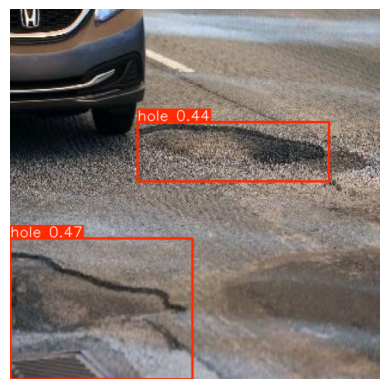

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

results = model_4("/content/dataset/test/images/p1359_jpg.rf.767c29752fab7b0a42df520399cbc589.jpg", conf=0.4)

annotated_img = results[0].plot()  # image with detections

plt.imshow(annotated_img)
plt.axis("off")